In [1]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import scipy as sc
import xarray as xr

plt.rcParams.update({'font.size': 12})

# choose colours
uc = "#298c8c"
cc = "#800074"

In [2]:
# load velocity and flash density datasets

# flash_density
FD = xr.open_mfdataset("..\\data\\flash_density_profiles.nc")

# velocity
velocity = xr.open_mfdataset("..\\data\\vertical_velocity.nc")

velocity = velocity.vert_vel.values
ubat = FD.ubat.values
cem = FD.cem.values

In [3]:
# create depth array 

depth = np.tile(FD.depth, 18)
depth = depth.reshape(18,600)

In [4]:
# define outliers as median +- 1.5 * IQR

# upper and lower limits
lim1 = np.nanmedian(velocity.flatten()) - 1.5*(np.nanpercentile(velocity.flatten(), 75)-np.nanpercentile(velocity.flatten(), 25))
lim2 = np.nanmedian(velocity.flatten()) + 1.5*(np.nanpercentile(velocity.flatten(), 75)-np.nanpercentile(velocity.flatten(), 25))

# seperate dataset into full, outliers excluded, and outliers
vel_full = velocity.copy()
inliers = velocity.copy()
outliers = velocity.copy()

# set outliers to nan for inlier dataset
inliers[inliers<lim1] = np.nan
inliers[inliers>lim2] = np.nan

# set inliers to nan for outlier dataset
outliers[(outliers>lim1) & (outliers<lim2)] = np.nan

In [5]:
# print outlier limits and median
print('Median: %0.3f' %np.nanmedian(velocity))
print('Outlier limits: %0.3f - %0.3f' %(lim1, lim2))

# print percentage of velocity outliers
vel = velocity.copy()
vel[np.isnan(cem)] = np.nan
len_vel = len(vel[~np.isnan(vel)])
len_vel_out = len(vel[(vel<lim1)|(vel>lim2)])
print(r'percentage outside %.3f - %.3f: %0.3f%%' %(lim1, lim2, (len_vel_out/len_vel)*100))

Median: 0.172
Outlier limits: 0.149 - 0.195
percentage outside 0.149 - 0.195: 1.004%


In [6]:
# calculate the linear correlation between velocity and biosealight flash density for inliers

x = inliers
y = cem
mask = ~np.isnan(x) & ~np.isnan(y)
res_inliers = sc.stats.linregress(x[mask],y[mask])
fitx_inliers = np.linspace(np.nanmin(x[mask]),np.nanmax(x[mask]),5)
# print the results
print(res_inliers)

LinregressResult(slope=np.float64(-74.12353499570835), intercept=np.float64(18.8932696494521), rvalue=np.float64(-0.03802665759126692), pvalue=np.float64(0.0004271835234797208), stderr=np.float64(21.033490740333953), intercept_stderr=np.float64(3.5765625382781447))


In [7]:
# print percentage of points where flash density is less than 5
u = ubat.copy()
len_u = len(u[~np.isnan(u)])
len_u_lt5 = len(u[u<5])
print(r'percentage UBAT flash density less than 5: %0.1f%%' %((len_u_lt5/len_u)*100))

c = cem.copy()
len_c = len(c[~np.isnan(c)])
len_c_lt5 = len(c[c<5])
print(r'percentage Biosealight flash density less than 5: %0.1f%%' %((len_c_lt5/len_c)*100))

percentage UBAT flash density less than 5: 60.9%
percentage Biosealight flash density less than 5: 80.3%


In [8]:
# repeat, with flash density values below 5 removed

x_inliers = inliers.copy()
y_inliers = cem.copy()
# remove values where biosealight flash density is below 5
y_inliers[y_inliers<5] = np.nan
mask_inliers = ~np.isnan(x_inliers) & ~np.isnan(y_inliers)
res_inliers = sc.stats.linregress(x_inliers[mask_inliers],y_inliers[mask_inliers])
fitx_inliers = np.linspace(np.nanmin(x_inliers[mask_inliers]),np.nanmax(x_inliers[mask_inliers]),5)
# print the results
print(res_inliers)

LinregressResult(slope=np.float64(-111.96343862112393), intercept=np.float64(47.90909386173428), rvalue=np.float64(-0.029777085908436984), pvalue=np.float64(0.23068919026647366), stderr=np.float64(93.37785694159227), intercept_stderr=np.float64(15.788232227514435))


In [9]:
# calculate the linear correlation between velocity and biosealight flash density for outliers

x_outliers = outliers
y_outliers = cem
mask_outliers = ~np.isnan(x_outliers) & ~np.isnan(y_outliers)
res_outliers = sc.stats.linregress(x_outliers[mask_outliers],y_outliers[mask_outliers])
fitx_outliers = np.linspace(np.nanmin(x_outliers[mask_outliers]),np.nanmax(x_outliers[mask_outliers]),5)
# print the results
print(res_outliers)

LinregressResult(slope=np.float64(78.6354535595348), intercept=np.float64(34.88732059501061), rvalue=np.float64(0.4511755357921125), pvalue=np.float64(1.1557970748400089e-05), stderr=np.float64(16.870971652538575), intercept_stderr=np.float64(5.192927091177613))


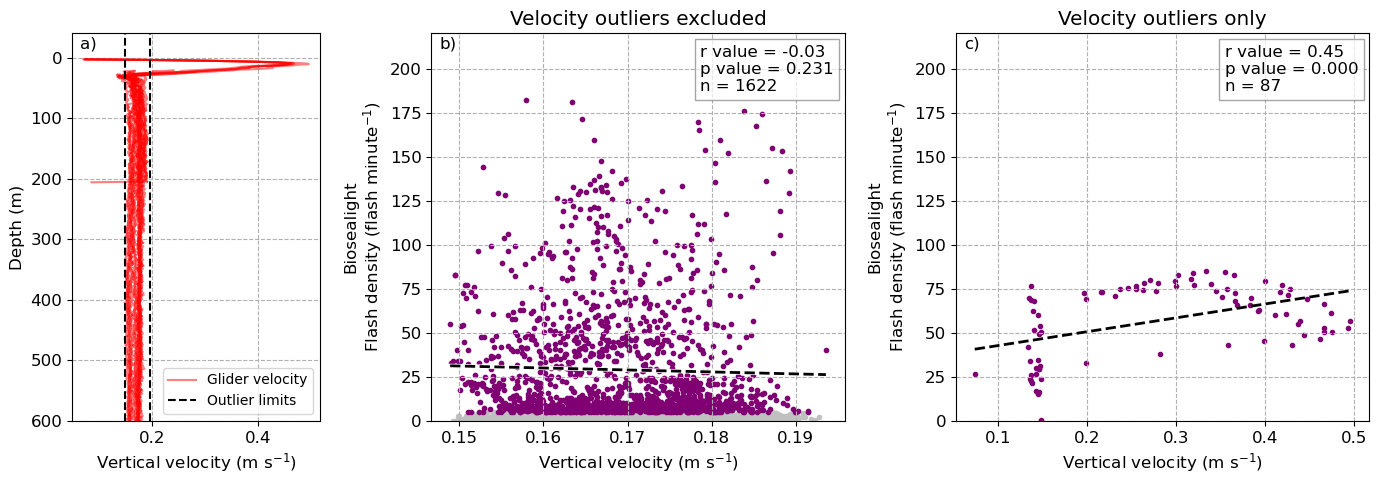

In [10]:
# plot the results

%matplotlib inline

plt.close()

fig, ax = plt.subplots(1,3, width_ratios=[0.6,1,1], figsize=(14,5))

#########################################
# VELOCITY PROFILES

for i in range(18):
    ax[0].plot(velocity[i], depth[i], c='r', alpha=0.5)
ax[0].plot(velocity[i], depth[i], c='r', alpha=0.5, label='Glider velocity')
ax[0].axvline(lim1, c='k', ls='--', label='Outlier limits')
ax[0].axvline(lim2, c='k', ls='--')

ax[0].set_ylabel('Depth (m)')
ax[0].set_xlabel('Vertical velocity (m s$^{-1}$)')
ax[0].legend(loc = 'lower right', fontsize=10)
ax[0].text(0.03,0.96, 'a)', transform=ax[0].transAxes)
ax[0].set_ylim(600,-40)

#########################################
# INLIERS

ax[1].scatter(inliers, cem, marker='.', c='silver')
ax[1].scatter(inliers[cem>=5], cem[cem>=5], marker='.', c=cc)
ax[1].plot(fitx_inliers, fitx_inliers*res_inliers.slope+res_inliers.intercept, c='white', lw=3)
ax[1].plot(fitx_inliers, fitx_inliers*res_inliers.slope+res_inliers.intercept, c='k', ls='--', lw=2)

txt = ("r value = %0.2f\np value = %0.3f\nn = %d" %(res_inliers.rvalue, res_inliers.pvalue, len(x_inliers[mask_inliers])))
ax[1].text(0.65, 0.85, txt, transform=ax[1].transAxes, fontsize=12, bbox=dict(fc='white', ec='grey', alpha=0.7))

ax[1].set_ylabel('Biosealight\nFlash density (flash minute$^{-1}$)')
ax[1].set_xlabel('Vertical velocity (m s$^{-1}$)')
ax[1].text(0.02,0.96, 'b)', transform=ax[1].transAxes)
ax[1].set_title('Velocity outliers excluded')
ax[1].set_ylim(0,220)

#########################################
# OUTLIERS

ax[2].scatter(outliers, cem, marker='.', c=cc, label='Biosealight')
ax[2].plot(fitx_outliers, fitx_outliers*res_outliers.slope+res_outliers.intercept, c='k', ls='--', lw=2)

txt = ("r value = %0.2f\np value = %0.3f\nn = %d" %(res_outliers.rvalue, res_outliers.pvalue, len(x_outliers[mask_outliers])))
ax[2].text(0.65,0.85, txt, transform=ax[2].transAxes, fontsize=12, bbox=dict(fc='white', ec='grey', alpha=0.7))

ax[2].set_ylabel('Biosealight\nFlash density (flash minute$^{-1}$)')
ax[2].set_xlabel('Vertical velocity (m s$^{-1}$)')
ax[2].text(0.02,0.96, 'c)', transform=ax[2].transAxes)
ax[2].set_title('Velocity outliers only')
ax[2].set_ylim(0,220)

#########################################
# FORMATING

for i in range(3):
    ax[i].grid(ls='--')

plt.tight_layout()
plt.show()

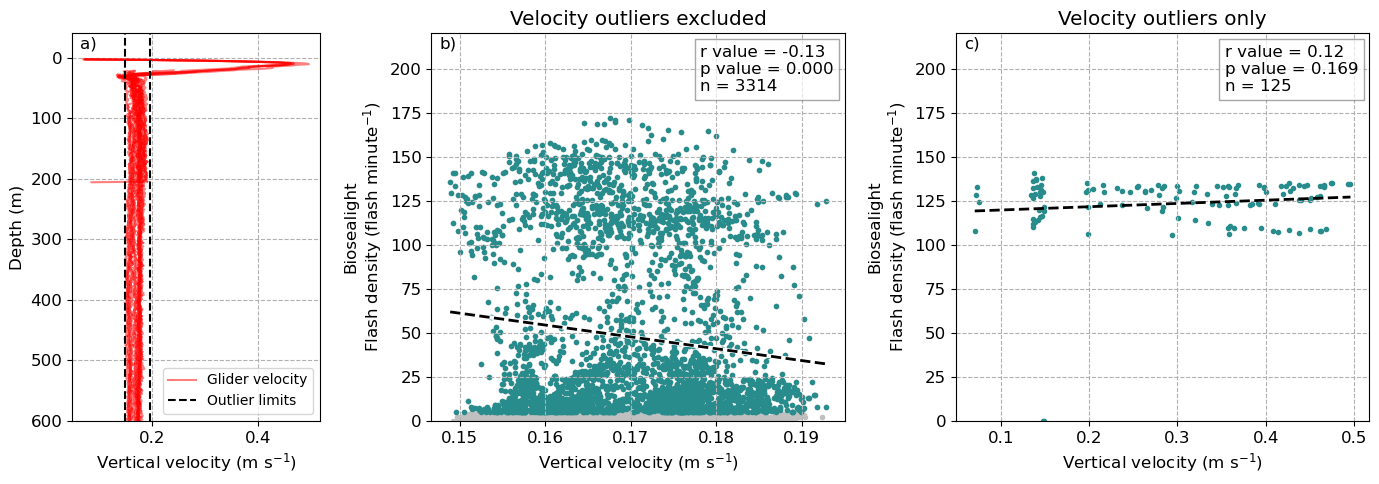

In [11]:
# repeat for UBAT

x_inliers = inliers.copy()
y_inliers = ubat.copy()
y_inliers[y_inliers<5] = np.nan
mask_inliers = ~np.isnan(x_inliers) & ~np.isnan(y_inliers)
res_inliers = sc.stats.linregress(x_inliers[mask_inliers],y_inliers[mask_inliers])
fitx_inliers = np.linspace(np.nanmin(x_inliers[mask_inliers]),np.nanmax(x_inliers[mask_inliers]),5)

outliers = velocity.copy()
outliers[(outliers>lim1) & (outliers<lim2)] = np.nan
x_outliers = outliers.copy()
y_outliers = ubat.copy()
mask_outliers = ~np.isnan(x_outliers) & ~np.isnan(y_outliers)
res_outliers = sc.stats.linregress(x_outliers[mask_outliers],y_outliers[mask_outliers])
fitx_outliers = np.linspace(np.nanmin(x_outliers[mask_outliers]),np.nanmax(x_outliers[mask_outliers]),5)


fig, ax = plt.subplots(1,3, width_ratios=[0.6,1,1], figsize=(14,5))

#########################################
# VELOCITY PROFILES

for i in range(18):
    ax[0].plot(velocity[i], depth[i], c='r', alpha=0.5)
ax[0].plot(velocity[i], depth[i], c='r', alpha=0.5, label='Glider velocity')
ax[0].axvline(lim1, c='k', ls='--', label='Outlier limits')
ax[0].axvline(lim2, c='k', ls='--')

ax[0].set_ylabel('Depth (m)')
ax[0].set_xlabel('Vertical velocity (m s$^{-1}$)')
ax[0].legend(loc = 'lower right', fontsize=10)
ax[0].text(0.03,0.96, 'a)', transform=ax[0].transAxes)
ax[0].set_ylim(600,-40)

#########################################
# INLIERS

ax[1].scatter(inliers, ubat, marker='.', c='silver')
ax[1].scatter(inliers[ubat>=5], ubat[ubat>=5], marker='.', c=uc)
ax[1].plot(fitx_inliers, fitx_inliers*res_inliers.slope+res_inliers.intercept, c='white', lw=3)
ax[1].plot(fitx_inliers, fitx_inliers*res_inliers.slope+res_inliers.intercept, c='k', ls='--', lw=2)

txt = ("r value = %0.2f\np value = %0.3f\nn = %d" %(res_inliers.rvalue, res_inliers.pvalue, len(x_inliers[mask_inliers])))
ax[1].text(0.65, 0.85, txt, transform=ax[1].transAxes, fontsize=12, bbox=dict(fc='white', ec='grey', alpha=0.7))

ax[1].set_ylabel('Biosealight\nFlash density (flash minute$^{-1}$)')
ax[1].set_xlabel('Vertical velocity (m s$^{-1}$)')
ax[1].text(0.02,0.96, 'b)', transform=ax[1].transAxes)
ax[1].set_title('Velocity outliers excluded')
ax[1].set_ylim(0,220)

#########################################
# OUTLIERS

ax[2].scatter(outliers, ubat, marker='.', c=uc)
ax[2].plot(fitx_outliers, fitx_outliers*res_outliers.slope+res_outliers.intercept, c='k', ls='--', lw=2)

txt = ("r value = %0.2f\np value = %0.3f\nn = %d" %(res_outliers.rvalue, res_outliers.pvalue, len(x_outliers[mask_outliers])))
ax[2].text(0.65,0.85, txt, transform=ax[2].transAxes, fontsize=12, bbox=dict(fc='white', ec='grey', alpha=0.7))

ax[2].set_ylabel('Biosealight\nFlash density (flash minute$^{-1}$)')
ax[2].set_xlabel('Vertical velocity (m s$^{-1}$)')
ax[2].text(0.02,0.96, 'c)', transform=ax[2].transAxes)
ax[2].set_title('Velocity outliers only')
ax[2].set_ylim(0,220)

#########################################
# FORMATING

for i in range(3):
    ax[i].grid(ls='--')

plt.tight_layout()
plt.show()